In [10]:
import sys
print(sys.executable)


C:\Users\filip\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe


In [1]:
import numpy as np
import pandas as pd
from torch import nn
import os
import torch
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import xgboost as xgb

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [4]:
df = pd.read_csv('data\XWines_Slim_150K_ratings.csv')

<>:1: SyntaxWarning: invalid escape sequence '\X'
<>:1: SyntaxWarning: invalid escape sequence '\X'
C:\Users\filip\AppData\Local\Temp\ipykernel_29840\4080725611.py:1: SyntaxWarning: invalid escape sequence '\X'
  df = pd.read_csv('data\XWines_Slim_150K_ratings.csv')
C:\Users\filip\AppData\Local\Temp\ipykernel_29840\4080725611.py:1: DtypeWarning: Columns (0: Vintage) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data\XWines_Slim_150K_ratings.csv')


In [5]:
df

,RatingID,UserID,WineID,Vintage,Rating,Date
0,143,1356810,103471,1950,4.5,2021-11-02 20:52:59
1,199,1173759,111415,1951,5.0,2015-08-20 17:46:26
2,348,1164877,111395,1952,5.0,2020-11-13 05:40:26
3,374,1207665,111433,1953,5.0,2017-05-05 06:44:13
4,834,1075841,111431,1955,5.0,2016-09-14 20:18:38
...,...,...,...,...,...,...
149995,21013438,1000052,111468,N.V.,4.5,2021-12-22 21:03:51
149996,21013467,1180844,111461,N.V.,4.0,2017-04-23 21:07:55
149997,21013494,1218581,113690,N.V.,3.5,2019-04-14 17:45:08
149998,21013505,1106198,111468,N.V.,4.5,2021-07-10 07:00:15


In [6]:
df.dtypes

RatingID      int64
UserID        int64
WineID        int64
Vintage      object
Rating      float64
Date            str
dtype: object

In [7]:
df = df[["Rating", "UserID", "WineID", "Date"]]
df.sort_values("Date", ascending = True, inplace=True)
df.reset_index(inplace=True)

In [8]:
# dane są JUŻ posortowane po Date rosnąco

split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx]
test_df  = df.iloc[split_idx:]

# trozbicie x y

X_train = train_df[["UserID", "WineID", "Date"]]
y_train = train_df["Rating"]

X_test  = test_df[["UserID", "WineID", "Date"]]
y_test  = test_df["Rating"]


In [9]:
X_train = X_train.copy()
X_test = X_test.copy()


In [10]:
X_train

,UserID,WineID,Date
0,1200775,155628,2012-04-19 20:46:00
1,1088812,167419,2012-04-21 19:04:41
2,1293899,179012,2012-05-15 00:01:18
3,1293899,111458,2012-05-15 00:51:03
4,1293899,111395,2012-05-15 00:54:22
...,...,...,...
119995,1070825,102055,2020-08-25 01:07:39
119996,1139402,179061,2020-08-25 01:28:38
119997,1107564,179021,2020-08-25 01:42:12
119998,1189563,179131,2020-08-25 01:47:56


In [11]:
users = X_train['UserID'].unique()
wines = X_train['WineID'].unique()
user2_id = {u: i for i, u in enumerate(users)}
wine2_id = {u: i for i, u in enumerate(wines)}

In [12]:
X_train['user_idx'] = X_train['UserID'].map(user2_id)
X_train['wine_idx'] = X_train['WineID'].map(wine2_id)

In [13]:
X_train


,UserID,WineID,Date,user_idx,wine_idx
0,1200775,155628,2012-04-19 20:46:00,0,0
1,1088812,167419,2012-04-21 19:04:41,1,1
2,1293899,179012,2012-05-15 00:01:18,2,2
3,1293899,111458,2012-05-15 00:51:03,2,3
4,1293899,111395,2012-05-15 00:54:22,2,4
...,...,...,...,...,...
119995,1070825,102055,2020-08-25 01:07:39,1222,648
119996,1139402,179061,2020-08-25 01:28:38,3026,12
119997,1107564,179021,2020-08-25 01:42:12,5616,15
119998,1189563,179131,2020-08-25 01:47:56,9361,174


In [14]:
# X_test['user_idx'] = X_test['UserID'].map(user2_id)
# X_test['wine_idx'] = X_test['WineID'].map(wine2_id)

# user_indices =  torch.tensor(X_test['user_idx'])
# wine_indices = torch.tensor(X_test['wine_idx'])

In [15]:
# X_train.copy()
# y_train.copy()

# X_train = X_train.dropna()
# y_train = y_train.loc[X_train.index]

# X_train['user_idx'] = X_train['user_idx'].astype(int)
# X_train['wine_idx'] = X_train['wine_idx'].astype(int)

# X_test_clean['user_idx'] = X_test_clean['user_idx'].astype(int)
# X_test_clean['wine_idx'] = X_test_clean['wine_idx'].astype(int)

# X_user_train = torch.tensor(X_train['user_idx'].values, dtype=torch.long)
# X_wine_train = torch.tensor(X_train['wine_idx'].values, dtype=torch.long)
# y_train_t = torch.tensor(y_train.values, dtype=torch.float32)

# X_user_test = torch.tensor(X_test_clean['user_idx'].values, dtype=torch.long)
# X_wine_test = torch.tensor(X_test_clean['wine_idx'].values, dtype=torch.long)
# y_test_t = torch.tensor(y_test_clean.values, dtype=torch.float32)

In [16]:
#map

X_test = X_test.copy()

X_test['user_idx'] = X_test['UserID'].map(user2_id)
X_test['wine_idx'] = X_test['WineID'].map(wine2_id)

#usuwanie cold start

mask = X_test['user_idx'].notna() & X_test['wine_idx'].notna()

X_test_clean = X_test.loc[mask].copy()
y_test_clean = y_test.loc[X_test_clean.index].copy()


#usuniecie null 

X_train = X_train.copy()
y_train = y_train.copy()

X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]



X_train['user_idx'] = X_train['user_idx'].astype(int)
X_train['wine_idx'] = X_train['wine_idx'].astype(int)

X_test_clean['user_idx'] = X_test_clean['user_idx'].astype(int)
X_test_clean['wine_idx'] = X_test_clean['wine_idx'].astype(int)


# konwersja do tensorów

X_user_train = torch.tensor(
    X_train['user_idx'].values,
    dtype=torch.long
)

X_wine_train = torch.tensor(
    X_train['wine_idx'].values,
    dtype=torch.long
)

y_train_t = torch.tensor(
    y_train.values,
    dtype=torch.float32
)


X_user_test = torch.tensor(
    X_test_clean['user_idx'].values,
    dtype=torch.long
)

X_wine_test = torch.tensor(
    X_test_clean['wine_idx'].values,
    dtype=torch.long
)

y_test_t = torch.tensor(
    y_test_clean.values,
    dtype=torch.float32
)


In [17]:
num_users = len(user2_id)
num_wines = len(wine2_id)

In [18]:
print(X_test.isnull().sum())

UserID         0
WineID         0
Date           0
user_idx    1782
wine_idx      22
dtype: int64


In [19]:
mask = X_test['user_idx'].notna() & X_test['wine_idx'].notna()

X_test_clean = X_test[mask]
y_test_clean = y_test[mask]

In [20]:
y_test_clean

120000    4.0
120001    4.5
120002    4.0
120003    3.0
120004    4.0
         ... 
149995    3.5
149996    4.0
149997    4.0
149998    4.5
149999    2.0
Name: Rating, Length: 28200, dtype: float64

In [21]:
print(y_test_clean.isnull().sum())

0


In [22]:
# funcke do metryk

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_regression_metrics(y_true, y_pred):
    """Oblicza podstawowe metryki regresji"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

def precision_at_k(y_true, y_pred, k=10, threshold=4.0):
    """
    Precision@K - ile z top-K rekomendacji to trafne rekomendacje
    threshold - ocena powyżej której wino jest uważane za 'dobre'
    """
    sorted_indices = np.argsort(y_pred)[::-1][:k]
    relevant = np.sum(y_true[sorted_indices] >= threshold)
    return relevant / k

def recall_at_k(y_true, y_pred, k=10, threshold=4.0):
    """
    Recall@K - jaka część wszystkich dobrych win została znaleziona w top-K
    """
    sorted_indices = np.argsort(y_pred)[::-1][:k]
    relevant_in_topk = np.sum(y_true[sorted_indices] >= threshold)
    total_relevant = np.sum(y_true >= threshold)
    if total_relevant == 0:
        return 0
    return relevant_in_topk / total_relevant

def ndcg_at_k(y_true, y_pred, k=10):
    """
    NDCG@K (Normalized Discounted Cumulative Gain)
    Mierzy jakość rankingu uwzględniając pozycję elementu
    """
    def dcg_at_k(r, k):
        r = np.asarray(r, dtype=np.float64)[:k] 
        if r.size:
            return np.sum(r / np.log2(np.arange(2, r.size + 2)))
        return 0.
    
    sorted_indices = np.argsort(y_pred)[::-1][:k]
    actual_dcg = dcg_at_k(y_true[sorted_indices], k)
    
    ideal_indices = np.argsort(y_true)[::-1][:k]
    ideal_dcg = dcg_at_k(y_true[ideal_indices], k)
    
    if ideal_dcg == 0:
        return 0
    return actual_dcg / ideal_dcg
    
def calculate_ranking_metrics_per_user(X_test_df, y_test_array, y_pred_array, k=10):
    """
    Oblicza metryki rankingowe dla każdego użytkownika osobno, potem uśrednia
    """
    X_test_df = X_test_df.copy()
    X_test_df['y_true'] = y_test_array
    X_test_df['y_pred'] = y_pred_array
    
    precision_scores = []
    recall_scores = []
    ndcg_scores = []
    
    for user_id in X_test_df['user_idx'].unique():
        user_data = X_test_df[X_test_df['user_idx'] == user_id]
        if len(user_data) < k:
            continue
            
        y_true_user = user_data['y_true'].values
        y_pred_user = user_data['y_pred'].values
        
        precision_scores.append(precision_at_k(y_true_user, y_pred_user, k))
        recall_scores.append(recall_at_k(y_true_user, y_pred_user, k))
        ndcg_scores.append(ndcg_at_k(y_true_user, y_pred_user, k))
    
    return {
        f'Precision@{k}': np.mean(precision_scores),
        f'Recall@{k}': np.mean(recall_scores),
        f'NDCG@{k}': np.mean(ndcg_scores)
    }

def calculate_coverage(model, user2_id, wine2_id, device, threshold=3.5):
    """
    Catalog Coverage - jaki procent win model potrafi rekomendować
    """
    model.eval()
    recommended_wines = set()
    
    with torch.no_grad():
        sample_users = np.random.choice(list(user2_id.values()), 
                                       min(100, len(user2_id)), 
                                       replace=False)
        
        for user_idx in sample_users:
            users_tensor = torch.tensor([user_idx] * len(wine2_id), 
                                       dtype=torch.long, device=device)
            wines_tensor = torch.tensor(list(wine2_id.values()), 
                                       dtype=torch.long, device=device)
            
            predictions = model(users_tensor, wines_tensor).squeeze().cpu().numpy()
            
            recommended = np.where(predictions >= threshold)[0]
            recommended_wines.update(recommended)
    
    coverage = len(recommended_wines) / len(wine2_id)
    return coverage

def evaluate_model(model, test_loader, X_test_df, y_test_array, 
                  user2_id, wine2_id, device, model_name):
    """
    Kompleksowa ewaluacja modelu
    """
    model.eval()
    all_preds = []
    all_true = []
    
    with torch.no_grad():
        for user, wine, rating in test_loader:
            user = user.to(device)
            wine = wine.to(device)
            preds = model(user, wine).squeeze().cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(rating.numpy())
    
    all_preds = np.array(all_preds)
    all_true = np.array(all_true)
    
   
    regression_metrics = calculate_regression_metrics(all_true, all_preds)
    
   
    ranking_metrics_10 = calculate_ranking_metrics_per_user(
        X_test_df, all_true, all_preds, k=10
    )
    ranking_metrics_5 = calculate_ranking_metrics_per_user(
        X_test_df, all_true, all_preds, k=5
    )
    
 
    coverage = calculate_coverage(model, user2_id, wine2_id, device)
    
   
    all_metrics = {
        'Model': model_name,
        **regression_metrics,
        **ranking_metrics_5,
        **ranking_metrics_10,
        'Coverage': coverage
    }
    
    return all_metrics, all_preds

# Model NCF


In [23]:
class NCF(nn.Module):
    def __init__(self, num_users, num_wines, embedding_dim=50):
        super(NCF, self).__init__()
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.wine_embedding = nn.Embedding(num_wines, embedding_dim)
        
        nn.init.normal_(self.user_embedding.weight, std=0.01)
        nn.init.normal_(self.wine_embedding.weight, std=0.01)
        
        self.layer1 = nn.Linear(embedding_dim*2, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.layer2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.layer3 = nn.Linear(64, 1)
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3) 
        
    def forward(self, user, wine):
        user_emb = self.user_embedding(user)
        wine_emb = self.wine_embedding(wine)
        x = torch.cat([user_emb, wine_emb], dim=1)
        
        x = self.relu(self.bn1(self.layer1(x)))
        x = self.dropout(x)
        
        x = self.relu(self.bn2(self.layer2(x)))
        x = self.dropout(x)
        
        x = self.layer3(x)
        return x

model_ncf = NCF(num_users, num_wines, embedding_dim=50)
print(model_ncf)

NCF(
  (user_embedding): Embedding(10357, 50)
  (wine_embedding): Embedding(1000, 50)
  (layer1): Linear(in_features=100, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer3): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)


In [24]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 2048
train_dataset = TensorDataset(X_user_train, X_wine_train, y_train_t)
test_dataset = TensorDataset(X_user_test, X_wine_test, y_test_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# Training


In [25]:
import torch.optim as optim
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model_ncf = model_ncf.to(device)

criterion = nn.MSELoss()

# Niższy learning rate + scheduler
optimizer = optim.Adam(model_ncf.parameters(), lr=0.003, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

epochs = 50
best_loss_ncf = float('inf')
patience = 5  # Większa cierpliwość
counter = 0

for epoch in range(epochs):
    # ===== TRAIN =====
    model_ncf.train()
    train_loss = 0
    
    for user, wine, rating in train_loader:
        user = user.to(device)
        wine = wine.to(device)
        rating = rating.to(device)
        
        optimizer.zero_grad()
        preds = model_ncf(user, wine).squeeze()
        loss = criterion(preds, rating)
        loss.backward()
        
        # Gradient clipping - zapobiega exploding gradients
        torch.nn.utils.clip_grad_norm_(model_ncf.parameters(), max_norm=1.0)
        
        optimizer.step()
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    
    # ===== TEST =====
    model_ncf.eval()
    test_loss = 0
    
    with torch.no_grad():
        for user, wine, rating in test_loader:
            user = user.to(device)
            wine = wine.to(device)
            rating = rating.to(device)
            
            preds = model_ncf(user, wine).squeeze()
            loss = criterion(preds, rating)
            test_loss += loss.item()
    
    test_loss /= len(test_loader)
    
    # Scheduler - zmniejsza learning rate gdy test loss się nie poprawia
    scheduler.step(test_loss)
    
    print(f"Epoch {epoch+1}/{epochs}  Train: {train_loss:.4f}  Test: {test_loss:.4f}")
    
    if test_loss < best_loss_ncf:
        best_loss_ncf = test_loss
        counter = 0
        torch.save(model_ncf.state_dict(), "best_model_ncf.pt")
        print(f"  ✓ New best model saved! (Test Loss: {test_loss:.4f})")
    else:
        counter += 1
    
    if counter >= patience:
        print(f"Early stopping triggered on epoch {epoch+1}")
        break

# Załaduj najlepszy model
model_ncf.load_state_dict(torch.load("best_model_ncf.pt"))
print(f"\n✓ Best NCF model loaded with Test Loss: {best_loss_ncf:.4f}")

Epoch 1/50  Train: 4.5039  Test: 0.4204
  ✓ New best model saved! (Test Loss: 0.4204)
Epoch 2/50  Train: 0.5370  Test: 0.3196
  ✓ New best model saved! (Test Loss: 0.3196)
Epoch 3/50  Train: 0.4145  Test: 0.2571
  ✓ New best model saved! (Test Loss: 0.2571)
Epoch 4/50  Train: 0.3608  Test: 0.2231
  ✓ New best model saved! (Test Loss: 0.2231)
Epoch 5/50  Train: 0.3260  Test: 0.2310
Epoch 6/50  Train: 0.2991  Test: 0.2549
Epoch 7/50  Train: 0.2793  Test: 0.2423
Epoch 8/50  Train: 0.2485  Test: 0.2295
Epoch 9/50  Train: 0.2338  Test: 0.2367
Early stopping triggered on epoch 9

✓ Best NCF model loaded with Test Loss: 0.2231


In [26]:
# Ewaluacja NCF
metrics_ncf, preds_ncf = evaluate_model(
    model_ncf, test_loader, X_test_clean, y_test_clean.values,
    user2_id, wine2_id, device, "NCF"
)


# XGBOOST

In [27]:
class GradientBoostingPyTorch(nn.Module):
    def __init__(self, num_users, num_wines, embedding_dim=32, n_trees=100):
        super(GradientBoostingPyTorch, self).__init__()
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.wine_embedding = nn.Embedding(num_wines, embedding_dim)
        
        self.n_trees = n_trees
        self.trees = nn.ModuleList([
            nn.Sequential(
                nn.Linear(embedding_dim*2, 64),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(64, 32),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(32, 1)
            ) for _ in range(n_trees)
        ])

        self.learning_rate = 0.05
        
    def forward(self, user, wine):
        user_emb = self.user_embedding(user)
        wine_emb = self.wine_embedding(wine)
        x = torch.cat([user_emb, wine_emb], dim=1)
        
        output = torch.zeros(x.shape[0], 1, device=x.device) # suma predykcji ze wszystkich drzew
        for tree in self.trees:
            output += self.learning_rate * tree(x)
        
        return output

In [28]:
model_gb = GradientBoostingPyTorch(num_users, num_wines, embedding_dim=32, n_trees=50)
print(model_gb)

GradientBoostingPyTorch(
  (user_embedding): Embedding(10357, 32)
  (wine_embedding): Embedding(1000, 32)
  (trees): ModuleList(
    (0-49): 50 x Sequential(
      (0): Linear(in_features=64, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
      (3): Linear(in_features=64, out_features=32, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.3, inplace=False)
      (6): Linear(in_features=32, out_features=1, bias=True)
    )
  )
)


In [29]:
model_gb = model_gb.to(device)
criterion_gb = nn.MSELoss()
optimizer_gb = optim.Adam(model_gb.parameters(), lr=0.001, weight_decay=1e-5)

In [30]:
epochs_gb = 20
best_loss_gb = float('inf')
patience_gb = 3
counter_gb = 0

for epoch in range(epochs_gb):
    # TRAIN
    model_gb.train()
    train_loss = 0
    for user, wine, rating in train_loader:
        user = user.to(device)
        wine = wine.to(device)
        rating = rating.to(device)
        optimizer_gb.zero_grad()
        preds = model_gb(user, wine).squeeze()
        loss = criterion_gb(preds, rating)
        loss.backward()
        optimizer_gb.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    
    # TEST
    model_gb.eval()
    test_loss = 0
    with torch.no_grad():
        for user, wine, rating in test_loader:
            user = user.to(device)
            wine = wine.to(device)
            rating = rating.to(device)
            preds = model_gb(user, wine).squeeze()
            loss = criterion_gb(preds, rating)
            test_loss += loss.item()
    test_loss /= len(test_loader)
    
    print(f"Epoch {epoch+1}/{epochs_gb}  Train: {train_loss:.4f}  Test: {test_loss:.4f}")

metrics_gb, preds_gb = evaluate_model(
    model_gb, test_loader, X_test_clean, y_test_clean.values,
    user2_id, wine2_id, device, "Gradient Boosting"
)

Epoch 1/20  Train: 3.9125  Test: 0.4329
Epoch 2/20  Train: 0.4473  Test: 0.3416
Epoch 3/20  Train: 0.3866  Test: 0.3064
Epoch 4/20  Train: 0.3505  Test: 0.2833
Epoch 5/20  Train: 0.3288  Test: 0.2724


KeyboardInterrupt: 

# Random Forest

In [29]:
class RandomForestPyTorch(nn.Module):
    def __init__(self, num_users, num_wines, embedding_dim=32, n_estimators=50):
        super(RandomForestPyTorch, self).__init__()
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.wine_embedding = nn.Embedding(num_wines, embedding_dim)
        
        self.n_estimators = n_estimators
        self.trees = nn.ModuleList([
            nn.Sequential(
                nn.Linear(embedding_dim*2, 128),
                nn.ReLU(),
                nn.Dropout(0.5),  
                nn.Linear(128, 64),
                nn.ReLU(),
                nn.Dropout(0.4),
                nn.Linear(64, 32),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(32, 1)
            ) for _ in range(n_estimators)
        ])
        
    def forward(self, user, wine, training=True):
        user_emb = self.user_embedding(user)
        wine_emb = self.wine_embedding(wine)
        x = torch.cat([user_emb, wine_emb], dim=1)
        
        outputs = []
        for tree in self.trees:
            if training:
                tree.train()
            else:
                tree.eval()
            outputs.append(tree(x))

        output = torch.stack(outputs).mean(dim=0)
        return output


In [30]:
model_rf = RandomForestPyTorch(num_users, num_wines, embedding_dim=32, n_estimators=30)
print(model_rf)

model_rf = model_rf.to(device)
criterion_rf = nn.MSELoss()
optimizer_rf = optim.Adam(model_rf.parameters(), lr=0.001, weight_decay=1e-5)

RandomForestPyTorch(
  (user_embedding): Embedding(10357, 32)
  (wine_embedding): Embedding(1000, 32)
  (trees): ModuleList(
    (0-29): 30 x Sequential(
      (0): Linear(in_features=64, out_features=128, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.5, inplace=False)
      (3): Linear(in_features=128, out_features=64, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.4, inplace=False)
      (6): Linear(in_features=64, out_features=32, bias=True)
      (7): ReLU()
      (8): Dropout(p=0.3, inplace=False)
      (9): Linear(in_features=32, out_features=1, bias=True)
    )
  )
)


In [31]:
epochs_rf = 20
best_loss_rf = float('inf')
patience_rf = 3
counter_rf = 0

for epoch in range(epochs_rf):
    # TRAIN
    model_rf.train()
    train_loss = 0
    for user, wine, rating in train_loader:
        user = user.to(device)
        wine = wine.to(device)
        rating = rating.to(device)
        optimizer_rf.zero_grad()
        preds = model_rf(user, wine, training=True).squeeze()
        loss = criterion_rf(preds, rating)
        loss.backward()
        optimizer_rf.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    
    model_rf.eval()
    test_loss = 0
    with torch.no_grad():
        for user, wine, rating in test_loader:
            user = user.to(device)
            wine = wine.to(device)
            rating = rating.to(device)
            preds = model_rf(user, wine, training=False).squeeze()
            loss = criterion_rf(preds, rating)
            test_loss += loss.item()
    test_loss /= len(test_loader)
    
    print(f"Epoch {epoch+1}/{epochs_rf}  Train: {train_loss:.4f}  Test: {test_loss:.4f}")
    
    if test_loss < best_loss_rf:
        best_loss_rf = test_loss
        counter_rf = 0
        torch.save(model_rf.state_dict(), "best_model_rf.pt")
    else:
        counter_rf += 1
    
    if counter_rf >= patience_rf:
        print("Early stopping triggered on epoch", epoch+1)
        break

rmse_rf = torch.sqrt(torch.tensor(best_loss_rf))
print(f"\n✓ Random Forest (PyTorch) Best RMSE: {rmse_rf.item():.6f}")

metrics_rf, preds_rf = evaluate_model(
    model_rf, test_loader, X_test_clean, y_test_clean.values,
    user2_id, wine2_id, device, "Random Forest"
)

Epoch 1/20  Train: 4.6235  Test: 0.4907
Epoch 2/20  Train: 0.4692  Test: 0.3599
Epoch 3/20  Train: 0.4070  Test: 0.3171
Epoch 4/20  Train: 0.3724  Test: 0.2973
Epoch 5/20  Train: 0.3507  Test: 0.2805
Epoch 6/20  Train: 0.3361  Test: 0.2742
Epoch 7/20  Train: 0.3274  Test: 0.2690
Epoch 8/20  Train: 0.3218  Test: 0.2650
Epoch 9/20  Train: 0.3162  Test: 0.2623
Epoch 10/20  Train: 0.3111  Test: 0.2566
Epoch 11/20  Train: 0.3062  Test: 0.2547
Epoch 12/20  Train: 0.3026  Test: 0.2563
Epoch 13/20  Train: 0.3013  Test: 0.2567
Epoch 14/20  Train: 0.2968  Test: 0.2509
Epoch 15/20  Train: 0.2939  Test: 0.2496
Epoch 16/20  Train: 0.2901  Test: 0.2510
Epoch 17/20  Train: 0.2872  Test: 0.2498
Epoch 18/20  Train: 0.2817  Test: 0.2467
Epoch 19/20  Train: 0.2799  Test: 0.2433
Epoch 20/20  Train: 0.2756  Test: 0.2496

✓ Random Forest (PyTorch) Best RMSE: 0.493245


In [32]:

# # PODSUMOWANIE WYNIKÓW - DODAJ NA KOŃCU


# print("SZCZEGÓŁOWE PODSUMOWANIE WYNIKÓW")


# results_df = pd.DataFrame([metrics_ncf, metrics_gb, metrics_rf])
# results_df = results_df.set_index('Model')

# print("\n" + results_df.to_string())
# print("\n" + "="*80)

# # Najlepszy model według różnych kryteriów
# print("\nNajlepsze modele według różnych metryk:")
# print("-" * 80)
# for metric in ['RMSE', 'MAE', 'R2', 'NDCG@10', 'Precision@10', 'Coverage']:
#     if metric == 'R2':
#         best_model = results_df[metric].idxmax()
#         best_value = results_df[metric].max()
#     else:
#         best_model = results_df[metric].idxmin() if metric in ['RMSE', 'MAE'] else results_df[metric].idxmax()
#         best_value = results_df[metric].min() if metric in ['RMSE', 'MAE'] else results_df[metric].max()
#     print(f"{metric:15s}: {best_model:25s} ({best_value:.4f})")

# print("="*80)

# # Wizualizacja wyników
# fig, axes = plt.subplots(2, 3, figsize=(18, 10))
# fig.suptitle('Porównanie modeli - różne metryki', fontsize=16, fontweight='bold')

# metrics_to_plot = ['RMSE', 'MAE', 'R2', 'NDCG@10', 'Precision@10', 'Coverage']
# for idx, metric in enumerate(metrics_to_plot):
#     row = idx // 3
#     col = idx % 3
#     ax = axes[row, col]
    
#     values = results_df[metric].values
#     models = results_df.index.values
    
#     bars = ax.bar(models, values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
#     ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
#     ax.set_ylabel(metric)
#     ax.tick_params(axis='x', rotation=45)
    
#     for bar in bars:
#         height = bar.get_height()
#         ax.text(bar.get_x() + bar.get_width()/2., height,
#                 f'{height:.4f}',
#                 ha='center', va='bottom', fontsize=9)
    
#     ax.grid(axis='y', alpha=0.3)

# plt.tight_layout()
# plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
# print("\nWykres zapisany jako 'model_comparison.png'")
# plt.show()


# results_df.to_csv('model_metrics.csv')
# print("Wyniki zapisane do 'model_metrics.csv'")

SZCZEGÓŁOWE PODSUMOWANIE WYNIKÓW

                       RMSE        R2  Precision@10
Model                                              
NCF                0.470788  0.331704      0.744633
Gradient Boosting  0.490891  0.273412      0.747458
Random Forest      0.525410  0.167632      0.737853


Najlepsze modele według różnych metryk:
------------------------------------------------------------
RMSE        : NCF                  (0.4708)
R2          : NCF                  (0.3317)
Precision@10: Gradient Boosting    (0.7475)

Wykres zapisany jako 'model_comparison.png'


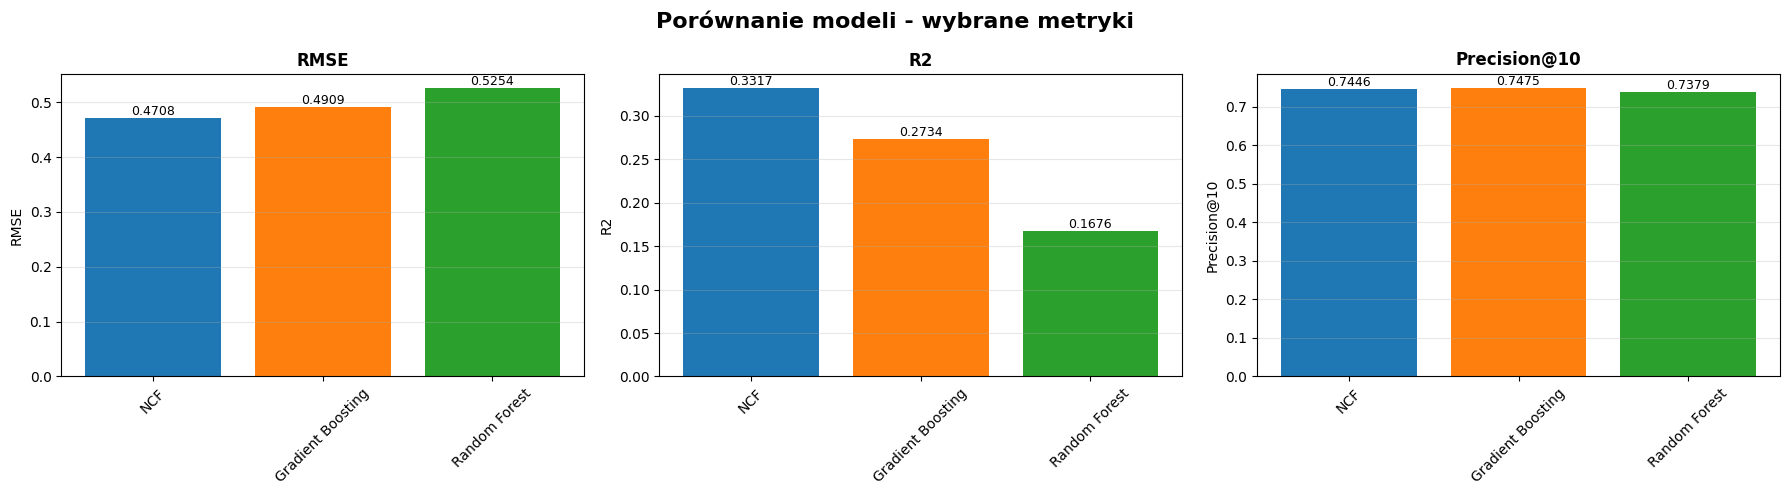

Wyniki zapisane do 'model_metrics.csv'


In [33]:
# PODSUMOWANIE WYNIKÓW - SKRÓCONE

print("SZCZEGÓŁOWE PODSUMOWANIE WYNIKÓW")

# Tworzymy DataFrame tylko z wybranych metryk
results_df = pd.DataFrame([metrics_ncf, metrics_gb, metrics_rf])
results_df = results_df.set_index('Model')
results_df = results_df[['RMSE', 'R2', 'Precision@10']]

print("\n" + results_df.to_string())
print("\n" + "="*60)

# Najlepszy model według wybranych metryk
print("\nNajlepsze modele według różnych metryk:")
print("-" * 60)
for metric in ['RMSE', 'R2', 'Precision@10']:
    if metric == 'R2':
        best_model = results_df[metric].idxmax()
        best_value = results_df[metric].max()
    else:
        best_model = results_df[metric].idxmin() if metric == 'RMSE' else results_df[metric].idxmax()
        best_value = results_df[metric].min() if metric == 'RMSE' else results_df[metric].max()
    print(f"{metric:12s}: {best_model:20s} ({best_value:.4f})")

print("="*60)

# Wizualizacja wyników (tylko RMSE, R2, Precision@10)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Porównanie modeli - wybrane metryki', fontsize=16, fontweight='bold')

metrics_to_plot = ['RMSE', 'R2', 'Precision@10']
for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    
    values = results_df[metric].values
    models = results_df.index.values
    
    bars = ax.bar(models, values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=45)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=9)
    
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
print("\nWykres zapisany jako 'model_comparison.png'")
plt.show()

# Zapis wyników
results_df.to_csv('model_metrics.csv')
print("Wyniki zapisane do 'model_metrics.csv'")
